## Data Processing for model training.

1. Check and combine test, train data from the WPD so I can use it later.
2. Keep only a subset of the features, based on correlation.

## IMPORTANT NOTE:
3. Add the timezone-aligned price data to the final dataset. Keeps data all in one place!!!


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from pyprojroot import here
import datetime as dt
import numpy as np
import holidays

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (12, 5)

ROOT_DIR = here()
DATA_DIR = ROOT_DIR / "1_data" / "raw" / "wpd_comp_data_2021"
PROCESSED_PRICE_DATA_DIR = ROOT_DIR / "1_data" / "processed"
SAVED_DIR = ROOT_DIR / "1_data" / "processed"

demand_train = pd.read_csv(DATA_DIR / "demand_train_set4.csv", parse_dates=["datetime"])
demand_test = pd.read_csv(DATA_DIR / "demand_test_set4.csv", parse_dates=["datetime"])
pv_train = pd.read_csv(DATA_DIR / "pv_train_set4.csv", parse_dates=["datetime"])
pv_test = pd.read_csv(DATA_DIR / "pv_test_set4.csv", parse_dates=["datetime"])
weather = pd.read_csv(DATA_DIR / "weather_train_set4.csv", parse_dates=["datetime"])

price = pd.read_csv(PROCESSED_PRICE_DATA_DIR / "gb_price.csv", parse_dates=["datetime"])

#demand_train["split"], demand_test["split"] = "train", "test"
#pv_train["split"], pv_test["split"] = "train", "test"

## EDA showed datasets are cut exatly at the same datetime, so we can just concatenate them and add a split column later if needed.
demand = pd.concat([demand_train, demand_test], ignore_index=True)
pv = pd.concat([pv_train, pv_test], ignore_index=True)

In [2]:
## resample to hourly data

demand_hourly = demand.set_index("datetime").resample("h").mean().reset_index()
pv_hourly = pv.set_index("datetime").resample("h").mean().reset_index()

print(demand_hourly.shape, pv_hourly.shape)
#demand_hourly.head()
pv_hourly.head()

(23520, 2) (23520, 4)


,datetime,irradiance_Wm-2,pv_power_mw,panel_temp_C
0,2017-11-03 00:00:00,0.0,0.0,7.215
1,2017-11-03 01:00:00,0.0,0.0,7.590
2,2017-11-03 02:00:00,0.0,0.0,7.240
3,2017-11-03 03:00:00,0.0,0.0,8.130
4,2017-11-03 04:00:00,0.0,0.0,7.765


In [3]:
pv_hourly[pv_hourly.isna().any(axis=1)]

,datetime,irradiance_Wm-2,pv_power_mw,panel_temp_C
617,2017-11-28 17:00:00,0.0,0.0,NaN
618,2017-11-28 18:00:00,0.0,0.0,NaN
619,2017-11-28 19:00:00,0.0,0.0,NaN
620,2017-11-28 20:00:00,0.0,0.0,NaN
621,2017-11-28 21:00:00,0.0,0.0,NaN
...,...,...,...,...
22014,2020-05-08 06:00:00,NaN,NaN,NaN
22015,2020-05-08 07:00:00,NaN,NaN,NaN
22016,2020-05-08 08:00:00,NaN,NaN,NaN
22017,2020-05-08 09:00:00,NaN,NaN,NaN


In [4]:

# Merge demand, pv, and weather on datetime (which has been shown to be aligned during EDA)


combined = demand.merge(pv, on="datetime").merge(weather, on="datetime")

combined['datetime'] = combined['datetime'].astype('datetime64[ns]')
combined["datetime"] = pd.to_datetime(combined["datetime"], utc=True)

print(f"Combined dataset shape: {combined.shape}")
print(combined.datetime.min(), combined.datetime.max())

## The fact that the data starts at 2021-01-01 00:00:00 and ends at 2021-12-31 23:00:00, further confirms that data is UTC aligned.
# It is the split is clean in UTC 0 and not local time, since the UK is in UTC+0 during winter and UTC+1 during summer.

Combined dataset shape: (23520, 17)
2017-11-03 00:00:00+00:00 2020-07-09 23:00:00+00:00


# Plot some graphs for further EDA

In [5]:
combined = combined.set_index("datetime")

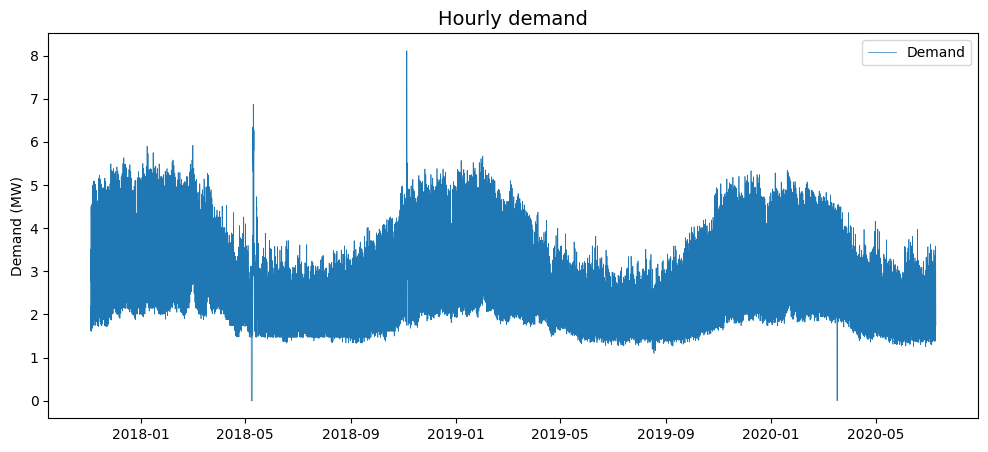

In [6]:
fig, ax = plt.subplots()
# Plot the sliced data
ax.plot(combined["demand_MW"], linewidth=0.5, label="Demand")
ax.set_title(f"Hourly demand", fontsize=14)
ax.set_ylabel("Demand (MW)")
ax.legend()
plt.show()

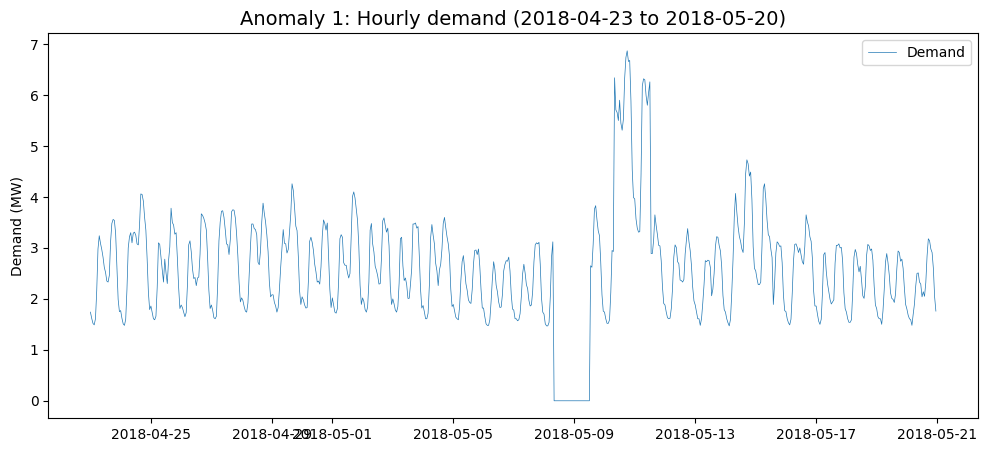

In [7]:
start_date1 = "2018-04-23"
start_of_anomaly = "2018-05-07"
end_date1 = "2018-05-20"


# Slice the data based on the datetime index
period_data1 = combined.loc[start_date1:end_date1, "demand_MW"]


fig, ax = plt.subplots()
# Plot the sliced data
ax.plot(period_data1, linewidth=0.5, label="Demand")
ax.set_title(f"Anomaly 1: Hourly demand ({start_date1} to {end_date1})", fontsize=14)
ax.set_ylabel("Demand (MW)")
ax.legend()
plt.show()

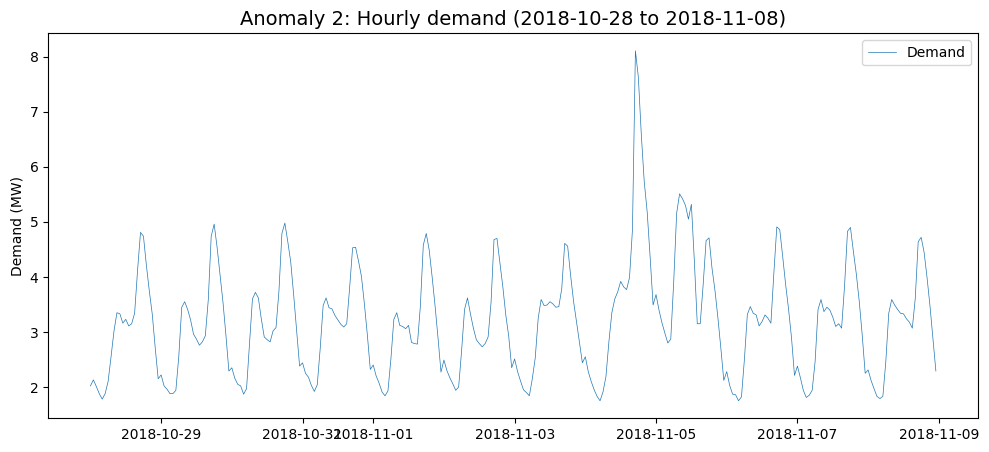

In [8]:
start_date2 = "2018-10-28"
start_of_anomaly1 = "2018-11-03"
end_date2 = "2018-11-08"


# Slice the data based on the datetime index
period_data2 = combined.loc[start_date2:end_date2, "demand_MW"]


fig, ax = plt.subplots()
# Plot the sliced data
ax.plot(period_data2, linewidth=0.5, label="Demand")
ax.set_title(f"Anomaly 2: Hourly demand ({start_date2} to {end_date2})", fontsize=14)
ax.set_ylabel("Demand (MW)")
ax.legend()
plt.show()

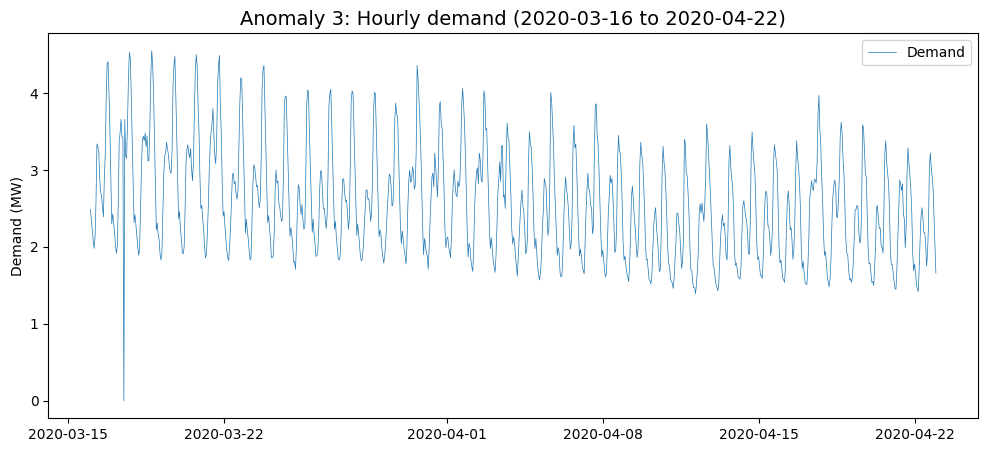

In [9]:
start_date3 = "2020-03-16"
end_date3 = "2020-04-22"

# Slice the data based on the datetime index
period_data3 = combined.loc[start_date3:end_date3, "demand_MW"]


fig, ax = plt.subplots()
# Plot the sliced data
ax.plot(period_data3, linewidth=0.5, label="Demand")
ax.set_title(f"Anomaly 3: Hourly demand ({start_date3} to {end_date3})", fontsize=14)
ax.set_ylabel("Demand (MW)")
ax.legend()
plt.show()

## Cleaning Dataset
Period 1:
- Replace two week period with two weeks preceding 
Period 2:
- Replace week with week preceding
Period 3: clip demand to <1 

In [10]:
# --- Anomaly 1 ---
# Replacement: 7 days (April 23 to May 6)
start_date1 = "2018-04-23"
end_replacement1 = "2018-05-06" 

# Target: 7 days (May 7 to May 20)
start_of_anomaly1 = "2018-05-07"
end_date1 = "2018-05-20"

# Extract raw values to bypass index alignment
anomaly1_replacment = combined.loc[start_date1:end_replacement1, "demand_MW"].values

# Assign the raw values to the target slice
combined.loc[start_of_anomaly1:end_date1, "demand_MW"] = anomaly1_replacment


# --- Anomaly 2 ---
# Target: 6 days (Nov 3 to Nov 8)
start_of_anomaly2 = "2018-11-03"
end_date2 = "2018-11-08"

# Replacement: 6 days (Oct 28 to Nov 2) 
start_date2 = "2018-10-28"
end_replacement2 = "2018-11-02"

# Extract raw values
anomaly2_replacment = combined.loc[start_date2:end_replacement2, "demand_MW"].values

# Assign the raw values
combined.loc[start_of_anomaly2:end_date2, "demand_MW"] = anomaly2_replacment


# --- Apply Global Thresholds ---
combined.loc[(combined["demand_MW"] > 6) | (combined["demand_MW"] < 1), "demand_MW"] = np.nan

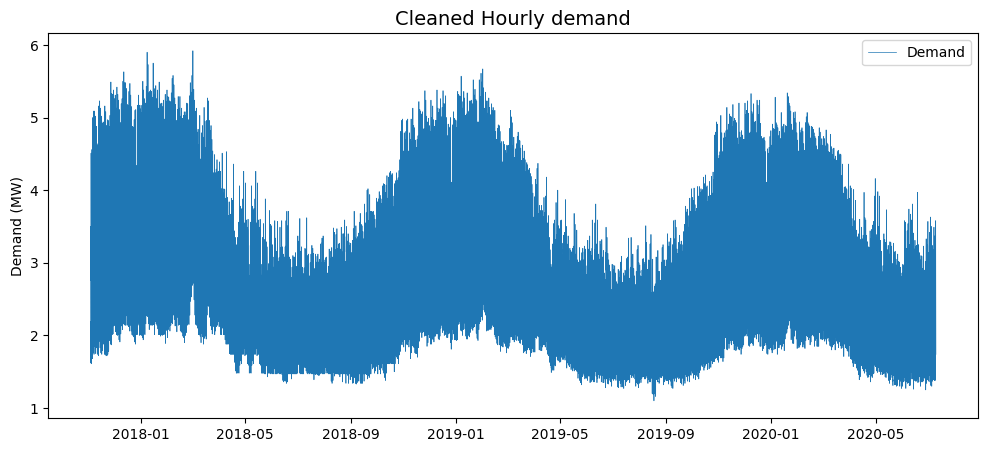

In [11]:
fig, ax = plt.subplots()
# Plot the sliced data
ax.plot(combined["demand_MW"], linewidth=0.5, label="Demand")
ax.set_title(f"Cleaned Hourly demand", fontsize=14)
ax.set_ylabel("Demand (MW)")
ax.legend()
plt.show()

/tmp/ipykernel_225813/3443562897.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


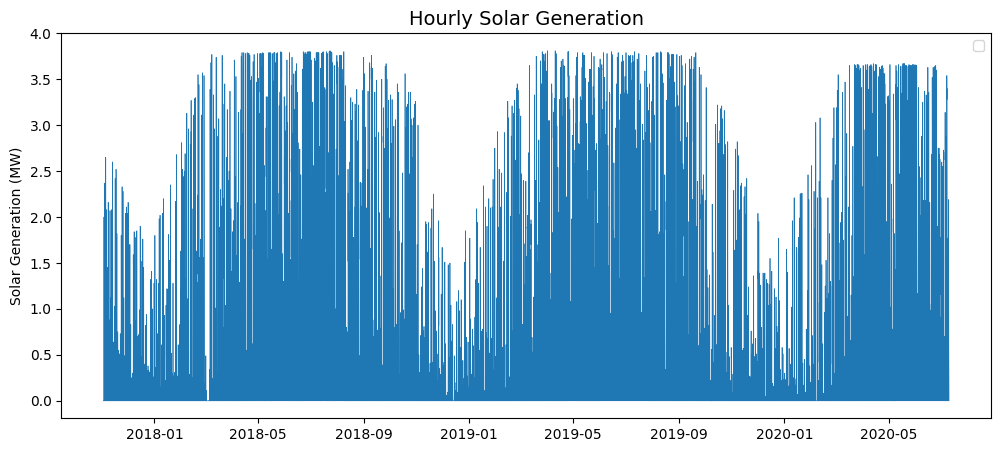

In [12]:
fig, ax = plt.subplots()
ax.plot(combined["pv_power_mw"], linewidth=0.5)
ax.set_title("Hourly Solar Generation", fontsize=14)
ax.set_ylabel("Solar Generation (MW)")
ax.legend()
plt.show()

/tmp/ipykernel_225813/3750128478.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


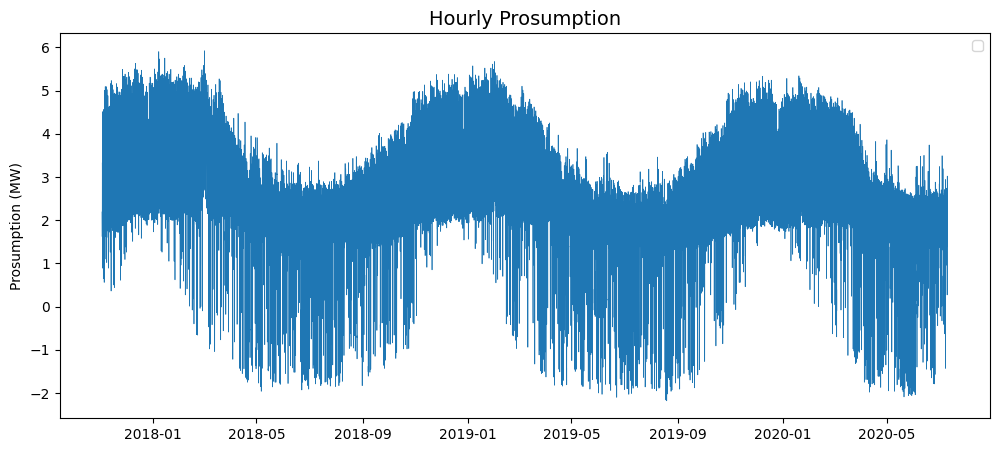

In [13]:
combined["prosumption"] = combined["demand_MW"] - combined["pv_power_mw"]

fig, ax = plt.subplots()
ax.plot(combined["prosumption"], linewidth=0.5)
ax.set_title("Hourly Prosumption", fontsize=14)
ax.set_ylabel("Prosumption (MW)")
ax.legend()
plt.show()

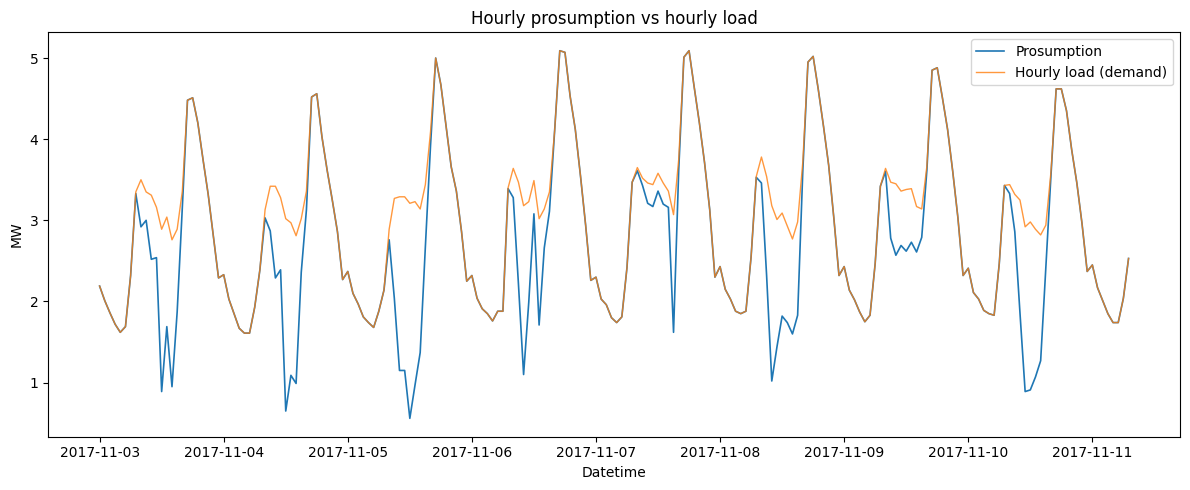

In [14]:
n = min(200, len(combined))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(combined["prosumption"].iloc[:n], label="Prosumption", linewidth=1.2)
ax.plot(combined["demand_MW"].iloc[:n], label="Hourly load (demand)", linewidth=1.0, alpha=0.8)

ax.set_title("Hourly prosumption vs hourly load")
ax.set_xlabel("Datetime")
ax.set_ylabel("MW")
ax.legend()
plt.tight_layout()
plt.show()

## Feature selection

In [15]:
combined = combined.reset_index()
possible_features = combined.columns.difference(["datetime", "demand_MW", "pv_power_mw", "prosumption"])
possible_features

Index(['irradiance_Wm-2', 'panel_temp_C', 'solar_location1', 'solar_location2',
       'solar_location3', 'solar_location4', 'solar_location5',
       'solar_location6', 'temp_location1', 'temp_location2', 'temp_location3',
       'temp_location4', 'temp_location5', 'temp_location6'],
      dtype='str')

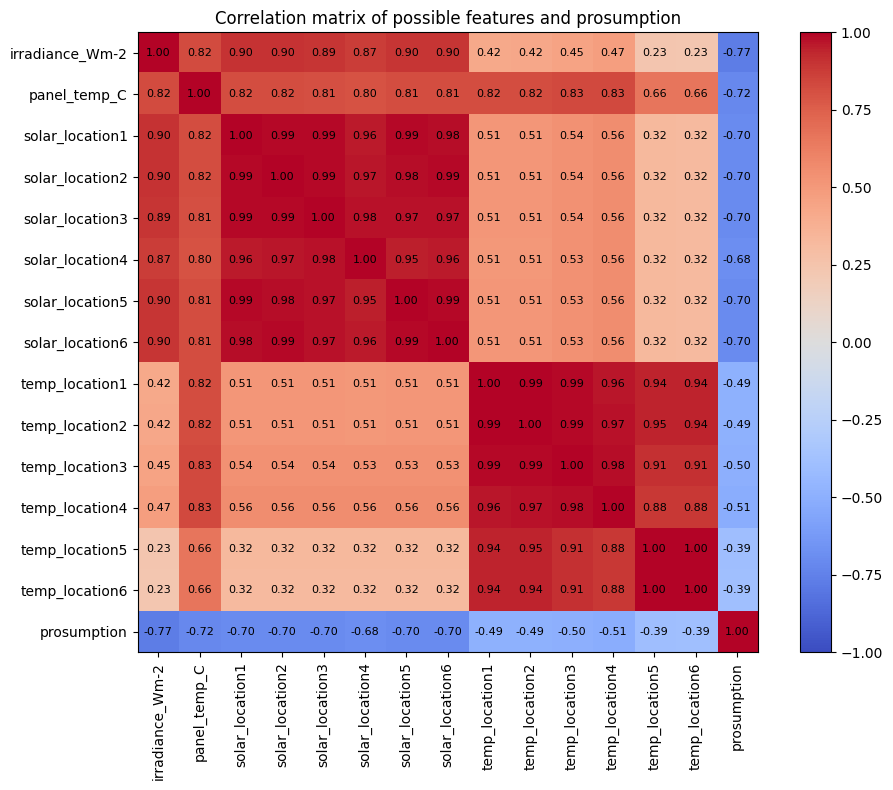

In [16]:
corr_matrix = combined[possible_features.tolist() + ["prosumption"]].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_matrix)))
ax.set_yticks(range(len(corr_matrix)))
ax.set_xticklabels(corr_matrix.columns, rotation=90)
ax.set_yticklabels(corr_matrix.index)

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                ha="center", va="center", color="black", fontsize=8)

fig.colorbar(im, ax=ax)
ax.set_title("Correlation matrix of possible features and prosumption")
plt.tight_layout()
plt.show()

In [17]:
corr_matrix["prosumption"].sort_values(ascending=False)

prosumption        1.000000
temp_location6    -0.389037
temp_location5    -0.394475
temp_location2    -0.486313
temp_location1    -0.490682
temp_location3    -0.499773
temp_location4    -0.508359
solar_location4   -0.682758
solar_location6   -0.697017
solar_location5   -0.697026
solar_location3   -0.697999
solar_location2   -0.701481
solar_location1   -0.701629
panel_temp_C      -0.718667
irradiance_Wm-2   -0.769076
Name: prosumption, dtype: float64

In [18]:
combined["datetime"].min(), combined["datetime"].max(), combined.shape

(Timestamp('2017-11-03 00:00:00+0000', tz='UTC'),
 Timestamp('2020-07-09 23:00:00+0000', tz='UTC'),
 (23520, 18))

In [19]:
missing = combined[list(possible_features)].isna().sum()
missing = missing[missing > 0]

if missing.empty:
    print("No missing values found in possible_features.")
else:
    print("Missing values in possible_features:")
    print(missing.to_frame(name="missing_count"))

Missing values in possible_features:
                 missing_count
irradiance_Wm-2             45
panel_temp_C                46
solar_location1             72
solar_location2             24
temp_location4              48


In [ ]:
combined

In [38]:
missing_pct = (combined.isna().mean() * 100).sort_values(ascending=False)
missing_pct_df = missing_pct.to_frame(name="missing_pct")
missing_pct_df

,missing_pct
solar_location1,0.306122
temp_location4,0.204082
panel_temp_C,0.195578
irradiance_Wm-2,0.191327
solar_location2,0.102041
prosumption,0.085034
pv_power_mw,0.080782
demand_MW,0.004252
datetime,0.000000
temp_location3,0.000000


# Chosen features:
## Chose solar_location3, panel_temp_C, temp_location3
- Decision made on criteria of correlation with prosumption, data availability and clarity of the variable.
- irradiance wasn't chosen as it isn't clear what the measurement is of / from.
- Solar_radiation is clearer as it is reanalysis of solar radiation data from a weather station.
- panel_temp_C is strongly negatively correlated with prosumption and explainable.
- temp_location3 was chosen over temp_location4 despite slightly lower correlation due to completeness of data.

In [20]:
combined["solar_location3"].describe()

count    23520.000000
mean       142.969852
std        224.168791
min          0.000000
25%          0.000000
50%          3.935000
75%        213.137500
max        934.750000
Name: solar_location3, dtype: float64

In [21]:
# Note on solar_location3
"""
Based on the statistical distribution, this variable is almost certainly Global Horizontal Irradiance (GHI) measured in Watts per square meter (W/m²).
In weather reanalysis datasets (such as ERA5 or MERRA-2), this is often labeled as "surface solar radiation downwards" (SSRD) or similar.
Here is the objective breakdown of why the summary statistics align with GHI:

While it is definitively W/m², it is possible it represents Direct Normal Irradiance (DNI) rather than GHI.
However, GHI is the standard baseline measurement in most weather station and reanalysis datasets used for solar power forecasting.
It is not Diffuse Horizontal Irradiance (DHI), as DHI rarely exceeds 400-500 W/m².
"""

'\nBased on the statistical distribution, this variable is almost certainly Global Horizontal Irradiance (GHI) measured in Watts per square meter (W/m²).\nIn weather reanalysis datasets (such as ERA5 or MERRA-2), this is often labeled as "surface solar radiation downwards" (SSRD) or similar.\nHere is the objective breakdown of why the summary statistics align with GHI:\n\nWhile it is definitively W/m², it is possible it represents Direct Normal Irradiance (DNI) rather than GHI.\nHowever, GHI is the standard baseline measurement in most weather station and reanalysis datasets used for solar power forecasting.\nIt is not Diffuse Horizontal Irradiance (DHI), as DHI rarely exceeds 400-500 W/m².\n'

In [22]:
price.loc[30:]

,datetime,da,imb,imb_up,imb_down,imb_sigma_proxy,imb_hat_proxy_sample_normal,imb_hat_proxy_sample_t,imb_fc,imb_up_fc,imb_down_fc,da_fc
30,2017-11-02 06:00:00+00:00,52.749764,64.56699,64.566990,52.749764,NaN,NaN,NaN,NaN,NaN,NaN,52.749764
31,2017-11-02 07:00:00+00:00,42.540708,95.31058,95.310580,42.540708,NaN,NaN,NaN,NaN,NaN,NaN,42.540708
32,2017-11-02 08:00:00+00:00,48.234220,45.63257,48.234220,45.632570,NaN,NaN,NaN,NaN,NaN,NaN,48.234220
33,2017-11-02 09:00:00+00:00,53.776024,35.39980,53.776024,35.399800,NaN,NaN,NaN,NaN,NaN,NaN,53.776024
34,2017-11-02 10:00:00+00:00,47.038404,35.13250,47.038404,35.132500,NaN,NaN,NaN,NaN,NaN,NaN,47.038404
...,...,...,...,...,...,...,...,...,...,...,...,...
24163,2020-08-03 19:00:00+00:00,38.494320,47.00000,47.000000,38.494320,7.875049,46.873961,27.181284,27.181284,38.494320,27.181284,38.494320
24164,2020-08-03 20:00:00+00:00,37.738824,39.31000,39.310000,37.738824,7.875049,24.028561,41.635608,41.635608,41.635608,37.738824,37.738824
24165,2020-08-03 21:00:00+00:00,32.261478,15.12500,32.261478,15.125000,7.875049,27.034724,27.518098,27.518098,32.261478,27.518098,32.261478
24166,2020-08-03 22:00:00+00:00,29.230500,26.77000,29.230500,26.770000,7.875049,26.233420,31.383259,31.383259,31.383259,29.230500,29.230500


In [23]:
features = ["solar_location3", "panel_temp_C", "temp_location3"]
price_columns = ["datetime", "da", "imb", "imb_up", "imb_down", "da_fc", "imb_fc", "imb_up_fc", "imb_down_fc"]

rename_dict = {
    "solar_location3": "solar_irrad", 
    "panel_temp_C": "panel_temp",
    "temp_location3": "ambient_temp",

}

df_full = combined[["datetime", "prosumption"] + features].merge(price[price_columns], on="datetime", how="left")
df_full = df_full.rename(columns=rename_dict)

In [24]:
df_full.index.is_monotonic_increasing

True

In [25]:
df_full.head()

,datetime,prosumption,solar_irrad,panel_temp,ambient_temp,da,imb,imb_up,imb_down,da_fc,imb_fc,imb_up_fc,imb_down_fc
0,2017-11-03 00:00:00+00:00,2.19,0.0,7.05,7.46,44.383875,39.163825,44.383875,39.163825,44.383875,45.693180,45.693180,44.383875
1,2017-11-03 01:00:00+00:00,2.01,0.0,7.70,7.14,40.505500,37.135480,40.505500,37.135480,40.505500,38.321406,40.505500,38.321406
2,2017-11-03 02:00:00+00:00,1.86,0.0,7.20,6.86,36.023625,35.330885,36.023625,35.330885,36.023625,35.577902,36.023625,35.577902
3,2017-11-03 03:00:00+00:00,1.72,0.0,7.97,6.60,37.204000,36.042370,37.204000,36.042370,37.204000,36.466106,37.204000,36.466106
4,2017-11-03 04:00:00+00:00,1.62,0.0,7.85,6.86,40.026250,36.400000,40.026250,36.400000,40.026250,39.953733,40.026250,39.953733


In [26]:
df_full.to_csv(SAVED_DIR / "df_full.csv", index=False)

# Extra: Prosumption Analysis

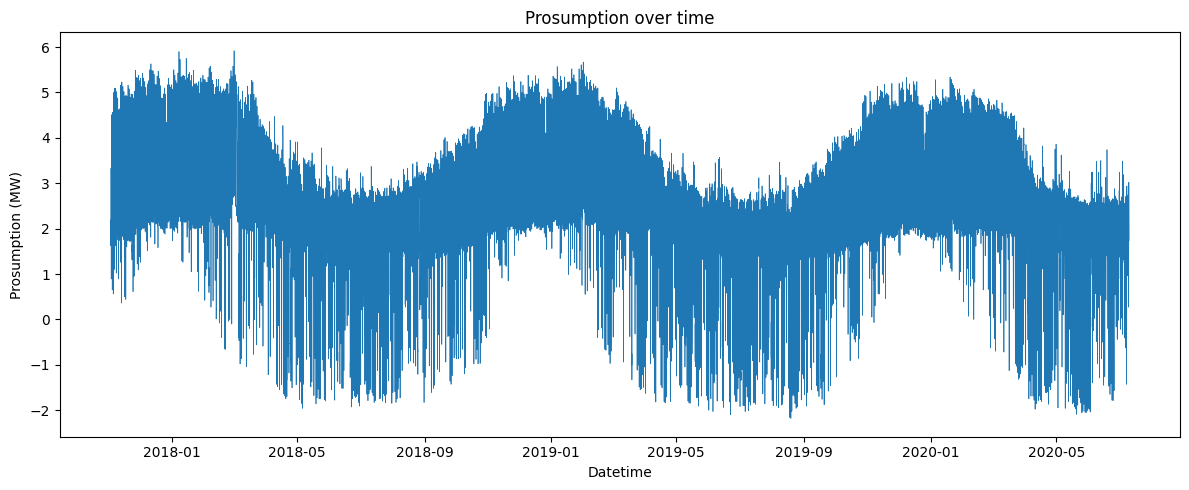

In [27]:
fig, ax = plt.subplots()
ax.plot(combined["datetime"], combined["prosumption"], linewidth=0.5)
ax.set_title("Prosumption over time")
ax.set_xlabel("Datetime")
ax.set_ylabel("Prosumption (MW)")
plt.tight_layout()
plt.show()

In [28]:
summary = []

for year in [2018, 2019, 2020]:
    mask = (
        (combined["datetime"].dt.year == year)
        & (combined["datetime"].dt.month.isin([1, 2, 3, 4, 5, 6]))
    )
    prosumption_values = combined.loc[mask, "prosumption"]
    summary.append(
        {
            "year": year,
            "mean_prosumption": prosumption_values.mean(),
            "std_prosumption": prosumption_values.std(),
            "count": prosumption_values.shape[0],
        }
    )

pd.DataFrame(summary)

,year,mean_prosumption,std_prosumption,count
0,2018,2.340559,1.455660,4344
1,2019,2.159926,1.420786,4344
2,2020,2.041284,1.426513,4368


In [29]:
years = [2018, 2019, 2020]

diurnal_profiles = {}
residual_stats = []
residuals_list = []

for year in years:
    mask = (
        (combined["datetime"].dt.year == year)
        & (combined["datetime"].dt.month <= 6)
    )
    period = combined.loc[mask, ["datetime", "prosumption"]].copy()
    period["hour"] = period["datetime"].dt.hour

    diurnal = period.groupby("hour")["prosumption"].mean()
    diurnal_profiles[year] = diurnal

    period = period.merge(diurnal.rename("diurnal_mean"), on="hour")
    period["residual"] = period["prosumption"] - period["diurnal_mean"]

    residuals_list.append(period)

    residual_stats.append(
        {
            "year": year,
            "count": period.shape[0],
            "residual_std": period["residual"].std(),
        }
    )

residual_summary = pd.DataFrame(residual_stats)
residuals = pd.concat(residuals_list, ignore_index=True)

residual_summary

,year,count,residual_std
0,2018,4344,1.169782
1,2019,4344,1.111956
2,2020,4368,1.148410


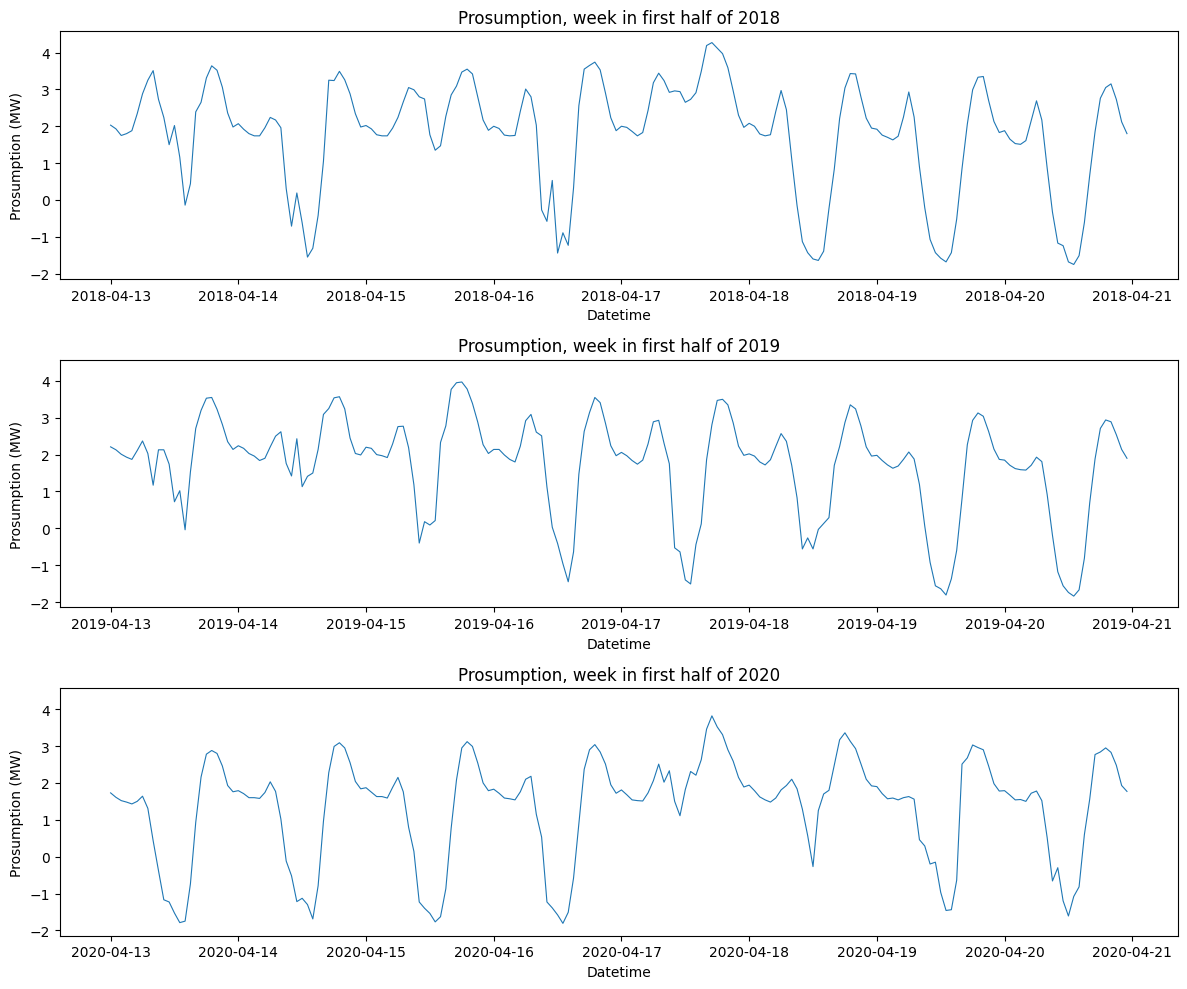

In [30]:
years = [2018, 2019, 2020]
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharey=True)

for year, ax in zip(years, axes):
    start = dt.datetime(year, 4, 13, tzinfo=dt.timezone.utc)
    end = dt.datetime(year, 4, 20, 23, 59, 59, tzinfo=dt.timezone.utc)
    yearly = combined.loc[
        (combined["datetime"] >= start) & (combined["datetime"] <= end),
        ["datetime", "prosumption"]
    ]
    ax.plot(yearly["datetime"], yearly["prosumption"], linewidth=0.8)
    ax.set_title(f"Prosumption, week in first half of {year}")
    ax.set_ylabel("Prosumption (MW)")
    ax.set_xlabel("Datetime")

plt.tight_layout()
plt.show()

In [31]:
months = {
    "before_lockdown_0": ["2018-04", "2018-05"],
    "before_lockdown_1": ["2019-04", "2019-05"],
    "before_lockdown_2": ["2019-06", "2019-07"],
    "before_lockdown_3": ["2019-08", "2019-09"],
    "during_lockdown": ["2020-04", "2020-05"],
    "after_lockdown": ["2020-06", "2020-07"]
}

summary = {}

for label, month_list in months.items():
    month_periods = pd.PeriodIndex(month_list, freq="M")
    mask = combined["datetime"].dt.to_period("M").isin(month_periods)
    summary[label] = combined.loc[mask, "prosumption"].describe()

pd.concat(summary, axis=1)

/tmp/ipykernel_225813/1400384363.py:14: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  mask = combined["datetime"].dt.to_period("M").isin(month_periods)
/tmp/ipykernel_225813/1400384363.py:14: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  mask = combined["datetime"].dt.to_period("M").isin(month_periods)
/tmp/ipykernel_225813/1400384363.py:14: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  mask = combined["datetime"].dt.to_period("M").isin(month_periods)
/tmp/ipykernel_225813/1400384363.py:14: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  mask = combined["datetime"].dt.to_period("M").isin(month_periods)
/tmp/ipykernel_225813/1400384363.py:14: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  mask = combined["datetime"].dt.to_period("M").isin(month_periods)


,before_lockdown_0,before_lockdown_1,before_lockdown_2,before_lockdown_3,during_lockdown,after_lockdown
count,1464.000000,1464.000000,1462.000000,1464.000000,1458.000000,936.000000
mean,1.765615,1.614665,1.249494,1.453989,1.249191,1.484327
std,1.372834,1.288924,1.262436,1.263346,1.383570,1.055692
min,-1.960000,-1.910000,-2.100000,-2.180000,-2.090000,-2.040000
25%,1.470000,1.260000,0.780000,1.197500,0.540000,1.280000
50%,1.970000,1.860000,1.500000,1.610000,1.590000,1.590000
75%,2.720000,2.450000,2.100000,2.350000,2.150000,2.220000
max,4.470000,4.250000,3.570000,4.020000,3.860000,3.740000


In [32]:
expected_idx = pd.date_range(df_full["datetime"].min(), df_full["datetime"].max(), freq="h")
actual_idx = pd.DatetimeIndex(df_full["datetime"])

missing = expected_idx.difference(actual_idx)
duplicates = df_full[df_full["datetime"].duplicated(keep=False)]

print(f"Expected hourly timestamps: {len(expected_idx)}")
print(f"Actual timestamps in df_full: {len(actual_idx)}")
print(f"Missing timestamps: {len(missing)}")
print(f"Duplicate datetime rows: {duplicates.shape[0]}")

if len(missing):
    print("Missing datetime values:")
    print(missing[:20])
else:
    print("No gaps found in the hourly datetime grid.")

Expected hourly timestamps: 23520
Actual timestamps in df_full: 23520
Missing timestamps: 0
Duplicate datetime rows: 0
No gaps found in the hourly datetime grid.


In [33]:
prosumption = df_full["prosumption"].copy()
prosumption.describe()

count    23500.000000
mean         2.215261
std          1.399359
min         -2.180000
25%          1.580000
50%          2.260000
75%          3.080000
max          5.920000
Name: prosumption, dtype: float64

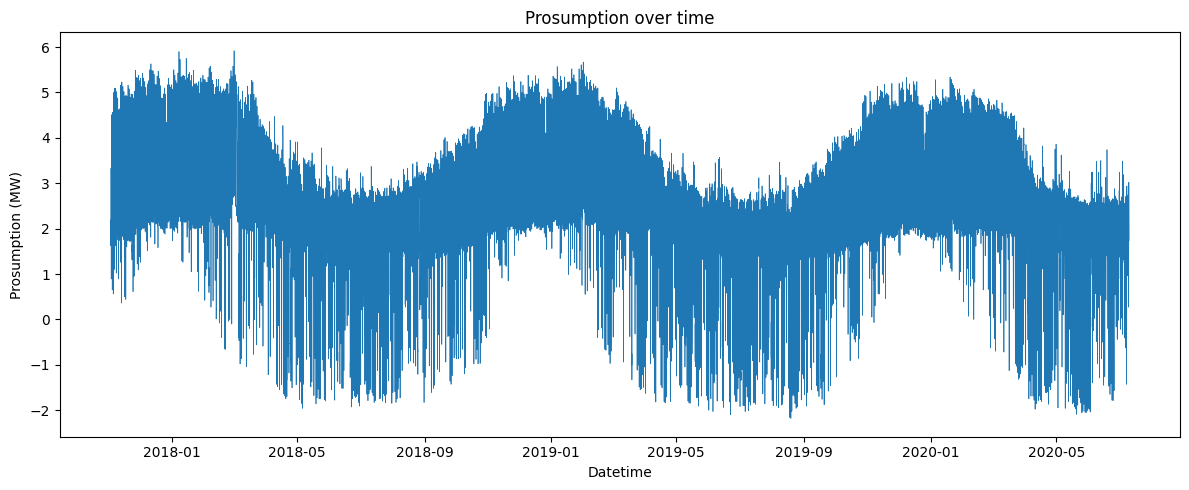

In [34]:
fig, ax = plt.subplots()
ax.plot(df_full["datetime"], df_full["prosumption"], linewidth=0.5)
ax.set_title("Prosumption over time")
ax.set_xlabel("Datetime")
ax.set_ylabel("Prosumption (MW)")
plt.tight_layout()
plt.show()

In [35]:
df_full_2018 = df_full[df_full["datetime"].dt.year == 2018].copy()
df_full_2018 = df_full_2018.reset_index(drop=True)

print(df_full_2018.shape)
df_full_2018.head()

(8760, 13)


,datetime,prosumption,solar_irrad,panel_temp,ambient_temp,da,imb,imb_up,imb_down,da_fc,imb_fc,imb_up_fc,imb_down_fc
0,2018-01-01 00:00:00+00:00,3.20,0.0,5.06,6.88,47.237883,55.940000,55.940000,47.237883,47.237883,76.214122,76.214122,47.237883
1,2018-01-01 01:00:00+00:00,2.83,0.0,6.27,6.88,54.715214,46.970000,54.715214,46.970000,54.715214,56.826499,56.826499,54.715214
2,2018-01-01 02:00:00+00:00,2.55,0.0,6.51,6.65,46.731096,62.905825,62.905825,46.731096,46.731096,49.683683,49.683683,46.731096
3,2018-01-01 03:00:00+00:00,2.28,0.0,6.11,6.59,39.982827,66.815530,66.815530,39.982827,39.982827,74.302860,74.302860,39.982827
4,2018-01-01 04:00:00+00:00,2.04,0.0,6.59,6.75,23.463349,62.718070,62.718070,23.463349,23.463349,79.165010,79.165010,23.463349


Average day-to-day hourly prosumption variability: 0.974 MW
Hourly profile summary:
             mean_prosumption  std_across_days
hour_of_day                                   
0                       2.137            0.439
1                       1.972            0.417
2                       1.866            0.398
3                       1.779            0.333
4                       1.736            0.274
5                       1.913            0.259
6                       2.337            0.459
7                       2.551            0.806
8                       2.412            1.165
9                       1.962            1.522
10                      1.480            1.715
11                      1.204            1.752
12                      1.043            1.842
13                      1.002            1.872
14                      1.144            1.837
15                      1.675            1.628
16                      2.643            1.420
17                     

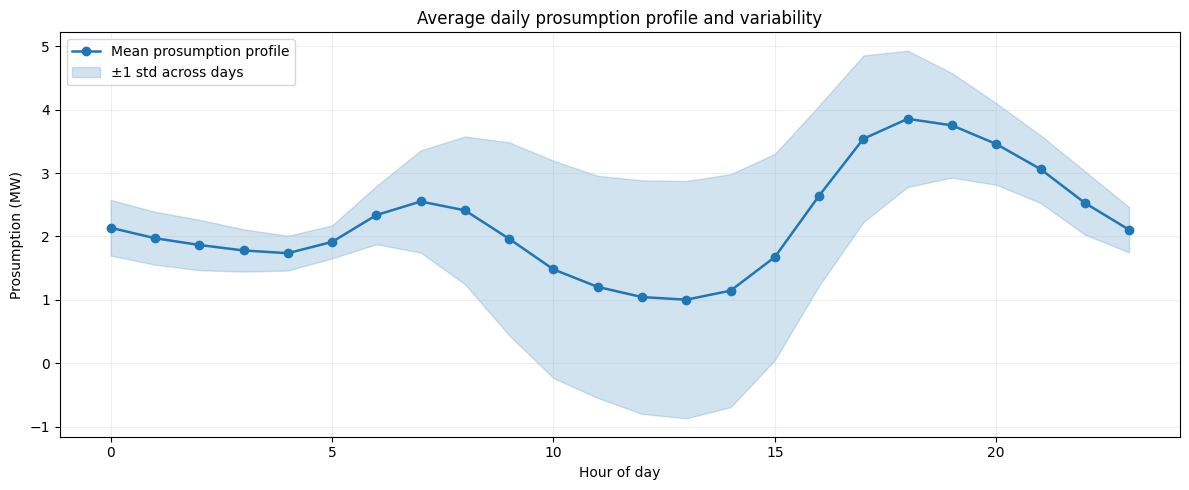

In [36]:
# Measure average prosumption variability over the course of a day
# (day-to-day variability of hourly profile, computed from df_full)

df_full = df_full.copy()
df_full["hour_of_day"] = df_full["datetime"].dt.hour

# Day x hour matrix: each row is a day, each column is an hour-of-day
daily_hourly_profile = (
    df_full.groupby([df_full["datetime"].dt.date.rename("date"), "hour_of_day"])["prosumption"]
    .mean()
    .unstack("hour_of_day")
)

daily_hourly_profile.index.name = "date"
daily_hourly_profile.columns.name = "hour_of_day"

# Mean prosumption profile across hours of the day
hourly_mean = daily_hourly_profile.mean(axis=0)

# Day-to-day variability at each hour of the day
hourly_std = daily_hourly_profile.std(axis=0, ddof=1)

# Overall average variability over the course of a day
avg_daily_variability = hourly_std.mean()

print(f"Average day-to-day hourly prosumption variability: {avg_daily_variability:.3f} MW")
print("Hourly profile summary:")
print(pd.DataFrame({
    "mean_prosumption": hourly_mean,
    "std_across_days": hourly_std
}).round(3))

# Plot the hourly mean profile with +/- one std day-to-day variability
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hourly_mean.index, hourly_mean, marker="o", linewidth=1.8, label="Mean prosumption profile")
ax.fill_between(
    hourly_mean.index,
    hourly_mean - hourly_std,
    hourly_mean + hourly_std,
    color="tab:blue",
    alpha=0.2,
    label="±1 std across days"
)
ax.set_title("Average daily prosumption profile and variability")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Prosumption (MW)")
ax.grid(alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()

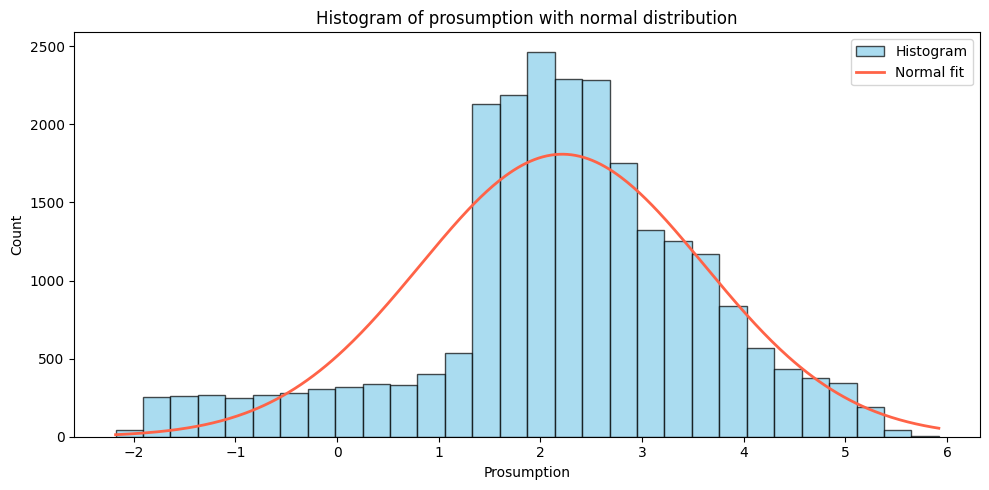

In [37]:
values = prosumption.dropna().astype(float)

mu = values.mean()
sigma = values.std(ddof=0)

fig, ax = plt.subplots(figsize=(10, 5))

n, bins, patches = ax.hist(
    values,
    bins=30,
    color="skyblue",
    edgecolor="black",
    alpha=0.7,
    label="Histogram",
)

bin_width = bins[1] - bins[0]
x = np.linspace(values.min(), values.max(), 400)
y = len(values) * bin_width * (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

ax.plot(x, y, color="tomato", linewidth=2, label="Normal fit")

ax.set_title("Histogram of prosumption with normal distribution")
ax.set_xlabel("Prosumption")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()